# Logistic regression: a companion notebook

**Human Language Technologies 2026-27, Lecture 06.** Claudio Gallicchio, University of Pisa.

This notebook lets you run the examples of the lecture and check the exercises of the exercise sheet. It follows Chapter 4 of Jurafsky and Martin, *Speech and Language Processing* (3rd edition draft, August 2026), sections 4.1 to 4.6, and Appendix B of the book for Naive Bayes.

1. Naive Bayes, a generative classifier
2. From features to a probability: the sigmoid
3. A feature extractor
4. The cross-entropy loss
5. Gradient descent by hand
6. A small sentiment dataset
7. Many examples at once
8. Learning the weights of the six features
9. Words as features, and negation
10. The learning rate and the size of the mini-batch

How to use it: run the cells from top to bottom (Jupyter, VS Code or Google Colab). Only the Python standard library, `numpy` and `matplotlib` are needed, and no internet connection. Sections 1 to 6 use plain Python, so that every formula is visible; from section 7 on, `numpy` computes the same quantities for many examples at once.

## 1. Naive Bayes, a generative classifier

The worked example of Appendix B: five short training reviews, and the test review *predictable with no fun*. Naive Bayes chooses the class c that maximizes P(c) Π<sub>i</sub> P(w<sub>i</sub> | c), with the prior P(c) = N<sub>c</sub> / N<sub>doc</sub> and add-one smoothed likelihoods P(w | c) = (count(w, c) + 1) / (Σ<sub>w'</sub> count(w', c) + |V|). Words never seen in training, such as *with*, are dropped. The book reports the two scores of the test review rounded down, as 6.1 × 10<sup>-5</sup> and 3.2 × 10<sup>-5</sup>.

In [1]:
from collections import Counter
import math, random

NB_TRAIN = [("-", "just plain boring"),
            ("-", "entirely predictable and lacks energy"),
            ("-", "no surprises and very few laughs"),
            ("+", "very powerful"),
            ("+", "the most fun film of the summer")]

def train_nb(docs):
    """Priors P(c), word counts per class and vocabulary of a multinomial Naive Bayes classifier."""
    classes = sorted(set(c for c, _ in docs))
    prior = {c: sum(1 for cc, _ in docs if cc == c) / len(docs) for c in classes}
    counts = {c: Counter(w for cc, d in docs if cc == c for w in d.split()) for c in classes}
    vocab = set(w for _, d in docs for w in d.split())
    return prior, counts, vocab

def nb_scores(model, doc):
    """P(c) times the product of the add-one likelihoods P(w | c), for each class; unknown words are dropped."""
    prior, counts, vocab = model
    scores = {}
    for c in prior:
        total = sum(counts[c].values())
        p = prior[c]
        for w in doc.split():
            if w in vocab:
                p *= (counts[c][w] + 1) / (total + len(vocab))
        scores[c] = p
    return scores

nb = train_nb(NB_TRAIN)
print("|V| =", len(nb[2]), " words in the negative reviews:", sum(nb[1]["-"].values()), " in the positive ones:", sum(nb[1]["+"].values()))
for test in ["predictable with no fun", "very boring and no fun"]:
    s = nb_scores(nb, test)
    print(f"{test:26s}  P(-) P(S|-) = {s['-']:.3g}   P(+) P(S|+) = {s['+']:.3g}   ->  {max(s, key=s.get)}")

|V| = 20  words in the negative reviews: 14  in the positive ones: 9
predictable with no fun     P(-) P(S|-) = 6.11e-05   P(+) P(S|+) = 3.28e-05   ->  -
very boring and no fun      P(-) P(S|-) = 3.17e-07   P(+) P(S|+) = 7.8e-08   ->  -


The second review is exercise 2 of the exercise sheet. Without smoothing, one word never seen with a class makes the whole product zero:

In [2]:
def nb_scores_unsmoothed(model, doc):
    prior, counts, vocab = model
    return {c: prior[c] * math.prod(counts[c][w] / sum(counts[c].values()) for w in doc.split() if w in vocab) for c in prior}

print(nb_scores_unsmoothed(nb, "very boring and no fun"))

{'+': 0.0, '-': 0.0}


In practice the products are computed as sums of logs, to avoid underflow on long documents. Naive Bayes is **generative**: it models how each class generates the words. Logistic regression, the subject of the rest of the notebook, is **discriminative**: it models P(y | x) directly.

## 2. From features to a probability: the sigmoid

Logistic regression computes a weighted sum of the features, z = Σ<sub>i</sub> w<sub>i</sub> x<sub>i</sub> + b (Eq. 4.2), and maps it to a probability with the sigmoid σ(z) = 1 / (1 + e<sup>-z</sup>) (Eq. 4.4). Its inverse is the logit, ln(p / (1 - p)). The values of exercise 3 of the exercise sheet:

In [3]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def logit(p):
    return math.log(p / (1 - p))

print(f"sigma(0) = {sigmoid(0)}   sigma(ln 3) = {sigmoid(math.log(3)):.4f}   sigma(-ln 3) = {sigmoid(-math.log(3)):.4f}")
print(f"sigma(2) = {sigmoid(2):.3f}   sigma(-2) = {sigmoid(-2):.3f}   sum = {sigmoid(2) + sigmoid(-2)}")
for p in (0.8, 0.9, 0.99):
    print(f"logit({p}) = {logit(p):.2f}")

sigma(0) = 0.5   sigma(ln 3) = 0.7500   sigma(-ln 3) = 0.2500
sigma(2) = 0.881   sigma(-2) = 0.119   sum = 0.9999999999999999
logit(0.8) = 1.39
logit(0.9) = 2.20
logit(0.99) = 4.60


The sentiment classifier of the lecture has six features and hand-set weights (section 4.3.1). On the sample review of the book the features are x = [3, 2, 1, 3, 0, ln 66], and the probability of the positive class is 0.70. The variants are exercise 4 of the exercise sheet.

In [4]:
BOOK_W = [2.5, -5.0, -1.2, 0.5, 2.0, 0.7]
BOOK_B = 0.1
FEATURE_NAMES = ["positive lexicon words", "negative lexicon words", "'no' in the review",
                 "1st and 2nd person pronouns", "'!' in the review", "ln(length)"]

def weighted_sum(w, x, b):
    return sum(wi * xi for wi, xi in zip(w, x)) + b

x = [3, 2, 1, 3, 0, math.log(66)]
for i, (name, wi, xi) in enumerate(zip(FEATURE_NAMES, BOOK_W, x), 1):
    print(f"x{i} = {xi:5.2f}   w{i} = {wi:5.1f}   w{i} x{i} = {wi * xi:6.2f}   {name}")
z = weighted_sum(BOOK_W, x, BOOK_B)
print(f"z = {z:.2f}   P(+ | x) = {sigmoid(z):.2f}   P(- | x) = {1 - sigmoid(z):.2f}")

for change, x_new in [("with an exclamation mark", x[:4] + [1] + x[5:]),
                      ("without the word no", x[:2] + [0] + x[3:]),
                      ("one more negative word", [x[0], x[1] + 1] + x[2:])]:
    z_new = weighted_sum(BOOK_W, x_new, BOOK_B)
    print(f"{change:26s} z = {z_new:5.2f}   P(+ | x) = {sigmoid(z_new):.3f}")

x1 =  3.00   w1 =   2.5   w1 x1 =   7.50   positive lexicon words
x2 =  2.00   w2 =  -5.0   w2 x2 = -10.00   negative lexicon words
x3 =  1.00   w3 =  -1.2   w3 x3 =  -1.20   'no' in the review
x4 =  3.00   w4 =   0.5   w4 x4 =   1.50   1st and 2nd person pronouns
x5 =  0.00   w5 =   2.0   w5 x5 =   0.00   '!' in the review
x6 =  4.19   w6 =   0.7   w6 x6 =   2.93   ln(length)
z = 0.83   P(+ | x) = 0.70   P(- | x) = 0.30
with an exclamation mark   z =  2.83   P(+ | x) = 0.944
without the word no        z =  2.03   P(+ | x) = 0.884
one more negative word     z = -4.17   P(+ | x) = 0.015


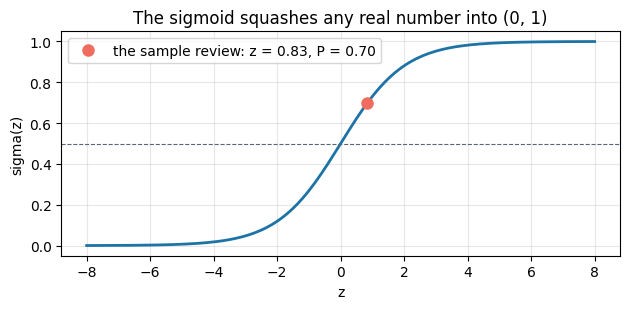

In [5]:
import matplotlib.pyplot as plt

zs = [i / 10 for i in range(-80, 81)]
plt.figure(figsize=(6.4, 3.2))
plt.plot(zs, [sigmoid(v) for v in zs], color="#1D73A6", lw=2)
plt.axhline(0.5, color="#596675", lw=0.8, ls="--")
plt.plot([z], [sigmoid(z)], "o", color="#F06C5F", ms=8, label=f"the sample review: z = {z:.2f}, P = {sigmoid(z):.2f}")
plt.xlabel("z"); plt.ylabel("sigma(z)"); plt.title("The sigmoid squashes any real number into (0, 1)")
plt.legend(loc="upper left"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. A feature extractor

The features are computed from the text by a small function. Here with the two lexicons of exercise 5 of the exercise sheet, on its review; tokens are separated by spaces and compared in lower case.

In [6]:
PRONOUNS = {"i", "me", "my", "mine", "we", "us", "our", "you", "your"}

def six_features(tokens, pos_lex, neg_lex):
    """The six features of the sentiment classifier of the lecture."""
    t = [w.lower() for w in tokens]
    return [sum(w in pos_lex for w in t), sum(w in neg_lex for w in t), int("no" in t),
            sum(w in PRONOUNS for w in t), int("!" in t), math.log(len(t))]

EX_POS = {"loved", "great", "nice", "enjoyable"}
EX_NEG = {"boring", "awful", "hokey", "second-rate"}
review = "I loved this film ! The acting is great , the plot is not boring , and the music is nice ."
xr = six_features(review.split(), EX_POS, EX_NEG)
zr = weighted_sum(BOOK_W, xr, BOOK_B)
print("x =", [round(v, 2) for v in xr], f"  ({len(review.split())} tokens)")
print(f"z = {zr:.2f}   P(+ | x) = {sigmoid(zr):.3f}")

x = [3, 1, 0, 1, 1, 3.09]   (22 tokens)
z = 7.26   P(+ | x) = 0.999


The review is classified as positive, but for a wrong reason in part: *not boring* adds one to x<sub>2</sub>, the count of negative words, whose weight is -5. Section 9 comes back to negation.

## 4. The cross-entropy loss

For one example, the loss is L<sub>CE</sub>(ŷ, y) = -[y ln ŷ + (1 - y) ln(1 - ŷ)] (Eq. 4.19; Eq. 4.20 writes it with the sigmoid of the weighted sum in place of ŷ), with natural logarithms: the negative log probability that the classifier gives to the correct label. On the sample review, ŷ = 0.70:

In [7]:
def ce_loss(y_hat, y):
    return -(y * math.log(y_hat) + (1 - y) * math.log(1 - y_hat))

y_hat = sigmoid(z)
print(f"if the review is positive (y = 1): loss = {ce_loss(y_hat, 1):.2f}")
print(f"if the review is negative (y = 0): loss = {ce_loss(y_hat, 0):.2f}   (with y_hat rounded to 0.70, as in the book: {-math.log(0.30):.2f})")

if the review is positive (y = 1): loss = 0.36
if the review is negative (y = 0): loss = 1.19   (with y_hat rounded to 0.70, as in the book: 1.20)


The values of exercise 9 of the exercise sheet, and the cost of a mini-batch, the average of the losses:

In [8]:
for p in (0.9, 0.5, 0.1):
    print(f"y_hat = {p}:  loss with y = 1: {ce_loss(p, 1):.3f}   loss with y = 0: {ce_loss(p, 0):.3f}")
batch = [(0.9, 1), (0.5, 1), (0.1, 0)]
print("cost of the mini-batch:", round(sum(ce_loss(p, y) for p, y in batch) / len(batch), 3))
print("y = 1 and y_hat going to 0:", [round(ce_loss(p, 1), 1) for p in (1e-2, 1e-4, 1e-8)])

y_hat = 0.9:  loss with y = 1: 0.105   loss with y = 0: 2.303
y_hat = 0.5:  loss with y = 1: 0.693   loss with y = 0: 0.693
y_hat = 0.1:  loss with y = 1: 2.303   loss with y = 0: 0.105
cost of the mini-batch: 0.301
y = 1 and y_hat going to 0: [4.6, 9.2, 18.4]


## 5. Gradient descent by hand

For logistic regression the derivative of the loss with respect to a weight is (ŷ - y) x<sub>j</sub>, and with respect to the bias it is ŷ - y (Eq. 4.26 and 4.28). A step of stochastic gradient descent moves the parameters against the gradient, scaled by the learning rate η: θ<sup>t+1</sup> = θ<sup>t</sup> - η ∇L (Eq. 4.24). The step of the lecture: x = [3, 2], y = 1, all weights 0, η = 0.1.

In [9]:
def gradient(w, b, x, y):
    """Gradient of the cross-entropy loss of one example with respect to w and b."""
    err = sigmoid(weighted_sum(w, x, b)) - y
    return [err * xi for xi in x], err

def sgd_step(w, b, x, y, eta):
    gw, gb = gradient(w, b, x, y)
    return [wi - eta * gi for wi, gi in zip(w, gw)], b - eta * gb

def loss(w, b, x, y):
    return ce_loss(sigmoid(weighted_sum(w, x, b)), y)

w0, b0 = [0.0, 0.0], 0.0
print("gradient:", gradient(w0, b0, [3, 2], 1))
w1, b1 = sgd_step(w0, b0, [3, 2], 1, eta=0.1)
print("new parameters:", [round(v, 3) for v in w1], round(b1, 3))
print(f"loss before {loss(w0, b0, [3, 2], 1):.2f}, after {loss(w1, b1, [3, 2], 1):.2f}, y_hat after {sigmoid(weighted_sum(w1, [3, 2], b1)):.2f}")

gradient: ([-1.5, -1.0], -0.5)
new parameters: [0.15, 0.1] 0.05
loss before 0.69, after 0.40, y_hat after 0.67


Is the formula of the gradient right? A numerical check: move one parameter by a small h and look at how the loss changes, (L(θ + h) - L(θ - h)) / 2h. The two lists should agree, at any point.

In [10]:
def numerical_gradient(w, b, x, y, h=1e-6):
    gw = []
    for j in range(len(w)):
        wp, wm = list(w), list(w)
        wp[j] += h; wm[j] -= h
        gw.append((loss(wp, b, x, y) - loss(wm, b, x, y)) / (2 * h))
    return gw, (loss(w, b + h, x, y) - loss(w, b - h, x, y)) / (2 * h)

w_test, b_test, x_test = [0.3, -0.8, 1.1], 0.2, [2.0, 1.0, -1.5]
for y_test in (0, 1):
    (ga, gab), (gn, gnb) = gradient(w_test, b_test, x_test, y_test), numerical_gradient(w_test, b_test, x_test, y_test)
    print(f"y = {y_test}: formula {[round(v, 6) for v in ga + [gab]]}   numerical {[round(v, 6) for v in gn + [gnb]]}")

y = 0: formula [0.322218, 0.161109, -0.241663, 0.161109]   numerical [0.322218, 0.161109, -0.241663, 0.161109]
y = 1: formula [-1.677782, -0.838891, 1.258337, -0.838891]   numerical [-1.677782, -0.838891, 1.258337, -0.838891]


Exercises 10, 11 and 12 of the exercise sheet: a step with a negative example (textbook exercise 4.3), two stochastic steps in a row, and the same two examples as a single mini-batch.

In [11]:
POS_EX, NEG_EX = ([3, 2], 1), ([2, 5], 0)

w, b = sgd_step([0.0, 0.0], 0.0, *NEG_EX, eta=0.1)
print("exercise 10, one step on the negative example:", [round(v, 3) for v in w], round(b, 3))

w, b = sgd_step([0.0, 0.0], 0.0, *POS_EX, eta=0.1)
print("exercise 11, after the positive example:     ", [round(v, 3) for v in w], round(b, 3))
before = loss(w, b, *NEG_EX)
w, b = sgd_step(w, b, *NEG_EX, eta=0.1)
print("             after the negative example:     ", [round(v, 3) for v in w], round(b, 3))
print(f"             loss on the negative example {before:.2f} -> {loss(w, b, *NEG_EX):.2f};"
      f" loss on the positive example {loss([0, 0], 0, *POS_EX):.2f} -> {loss(w, b, *POS_EX):.2f}")

grads = [gradient([0.0, 0.0], 0.0, *ex) for ex in (POS_EX, NEG_EX)]
gw = [sum(g[0][j] for g in grads) / 2 for j in range(2)]
gb = sum(g[1] for g in grads) / 2
print("exercise 12, mini-batch gradient:", gw, gb, " new parameters:", [round(-0.1 * v, 3) for v in gw], round(-0.1 * gb, 3) + 0.0)

exercise 10, one step on the negative example: [-0.1, -0.25] -0.05
exercise 11, after the positive example:      [0.15, 0.1] 0.05
             after the negative example:      [0.01, -0.25] -0.02
             loss on the negative example 1.21 -> 0.25; loss on the positive example 0.69 -> 0.97
exercise 12, mini-batch gradient: [-0.25, 0.75] 0.0  new parameters: [0.025, -0.075] 0.0


## 6. A small sentiment dataset

To train a classifier we need many labeled reviews. Here we generate them from templates: each review praises or criticizes a few aspects of a film, sometimes with a negation (*the plot is not boring*), sometimes with an exclamation mark or the word *no*. The label is the opinion of the majority of the aspects, and 5% of the labels are flipped, as real annotations are never perfectly consistent. The reviews are artificial, but they have the properties that make the six features of the lecture useful, and negation that makes them fail.

In [12]:
POS_WORDS = ["great", "nice", "enjoyable", "wonderful", "brilliant", "moving", "fun", "superb"]
NEG_WORDS = ["boring", "awful", "hokey", "second-rate", "dull", "predictable", "weak", "terrible"]
ASPECTS = ["the acting", "the plot", "the music", "the script", "the cast", "the ending", "the dialogue", "the photography"]
OPENERS = ["i saw this film last week .", "we watched it on sunday .", "my friends told me to see it .",
           "it is the second film of a young director .", "", "", ""]
CLOSERS = {1: ["you will love it !", "go and see it !", "i recommend it to you .", "", ""],
           0: ["you will hate it .", "save your money !", "i want my evening back .", "", ""]}
NO_PHRASES = {1: ["no film this year is better ."], 0: ["there are no surprises .", "no one laughed ."]}

def clause(rng, polarity):
    """One aspect with a positive (1) or negative (0) opinion; one in five is expressed with a negation."""
    aspect = rng.choice(ASPECTS)
    if rng.random() < 0.2:
        return f"{aspect} is not {rng.choice(NEG_WORDS if polarity else POS_WORDS)}"
    return f"{aspect} is {'very ' if rng.random() < 0.3 else ''}{rng.choice(POS_WORDS if polarity else NEG_WORDS)}"

def make_review(rng):
    label = int(rng.random() < 0.5)
    n = rng.randint(2, 4)
    agree = rng.randint(n // 2 + 1, n)                      # the majority of the aspects agrees with the label
    polarities = [label] * agree + [1 - label] * (n - agree)
    rng.shuffle(polarities)
    body = clause(rng, polarities[0])
    for prev, pol in zip(polarities, polarities[1:]):
        body += (" but " if pol != prev else rng.choice([" , ", " and "])) + clause(rng, pol)
    parts = [rng.choice(OPENERS), body + " ."]
    if rng.random() < (0.25 if label == 0 else 0.08):
        parts.append(rng.choice(NO_PHRASES[label]))
    parts.append(rng.choice(CLOSERS[label]))
    if rng.random() < 0.05:                                 # label noise
        label = 1 - label
    return " ".join(p for p in parts if p).split(), label

rng = random.Random(2026)
data = [make_review(rng) for _ in range(2000)]
train_data, test_data = data[:1500], data[1500:]
print(len(train_data), "training reviews,", len(test_data), "test reviews,", f"{sum(y for _, y in train_data) / len(train_data):.0%} positive in training")
for tokens, y in data[:6]:
    print("+" if y else "-", " ".join(tokens))

1500 training reviews, 500 test reviews, 49% positive in training
+ the photography is wonderful but the acting is very awful but the photography is not terrible and the script is moving .
- the photography is not brilliant , the ending is weak . you will hate it .
- the dialogue is boring , the music is awful and the photography is not wonderful , the photography is dull . i want my evening back .
- the cast is very hokey and the photography is very terrible and the photography is boring and the ending is terrible .
- i saw this film last week . the plot is predictable , the script is terrible . no one laughed .
- the cast is enjoyable but the acting is terrible , the script is very dull , the dialogue is dull . save your money !


## 7. Many examples at once

With m examples as the rows of a matrix X (m × f), all the predictions are one matrix product, ŷ = σ(Xw + b) (Eq. 4.13). From here on we use `numpy`. First the numbers of exercise 8 of the exercise sheet, then the mini-batch gradient of the cost, (1/m) X<sup>T</sup>(ŷ - y) for the weights and the mean of ŷ - y for the bias (Eq. 4.32), checked on exercise 12.

In [13]:
import numpy as np

def predict(X, w, b):
    return 1 / (1 + np.exp(-(X @ w + b)))

X8, w8 = np.array([[3, 2], [1, 4], [0, 0]]), np.array([1, -1])
print("Xw + b =", X8 @ w8 + 0.5, "  y_hat =", predict(X8, w8, 0.5).round(2), "  decisions =", (predict(X8, w8, 0.5) > 0.5).astype(int))

def cost(X, y, w, b):
    p = np.clip(predict(X, w, b), 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def batch_gradient(X, y, w, b):
    err = predict(X, w, b) - y
    return X.T @ err / len(y), err.mean()

X12, y12 = np.array([[3.0, 2.0], [2.0, 5.0]]), np.array([1, 0])
print("exercise 12:", batch_gradient(X12, y12, np.zeros(2), 0.0))

Xw + b = [ 1.5 -2.5  0.5]   y_hat = [0.82 0.08 0.62]   decisions = [1 0 1]
exercise 12: (array([-0.25,  0.75]), np.float64(0.0))


A training function for the rest of the notebook: at each epoch the training examples are shuffled and split into mini-batches of the given size, with one update per mini-batch. With `batch_size=1` it is stochastic gradient descent, with `batch_size=len(y)` it is batch training. It records the cost on the whole training set after each epoch.

In [14]:
def train_lr(X, y, eta=0.1, epochs=30, batch_size=16, seed=0):
    rng = np.random.default_rng(seed)
    w, b = np.zeros(X.shape[1]), 0.0
    history = [cost(X, y, w, b)]
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            idx = order[start:start + batch_size]
            gw, gb = batch_gradient(X[idx], y[idx], w, b)
            w, b = w - eta * gw, b - eta * gb
        history.append(cost(X, y, w, b))
    return w, b, history

def accuracy(X, y, w, b):
    return np.mean((predict(X, w, b) > 0.5) == y)

## 8. Learning the weights of the six features

The six features of the lecture on the generated reviews, with the lexicons of the templates. First the hand-set weights of the book, then weights learned from the training set. The features have different ranges (counts up to 4, a log length around 3), so we standardize them with the mean and standard deviation of the training set (section 4.3.2, Eq. 4.9); exercise 7 of the exercise sheet is a check of the formula.

In [15]:
import statistics
values = [2, 4, 4, 6, 9]
mu, sd = statistics.mean(values), statistics.pstdev(values)
print(f"exercise 7: mean {mu}, standard deviation {sd:.2f}, z-scores {[round((v - mu) / sd, 2) for v in values]},"
      f" normalized {[round((v - min(values)) / (max(values) - min(values)), 2) for v in values]}")

def six_matrix(dataset):
    X = np.array([six_features(t, set(POS_WORDS), set(NEG_WORDS)) for t, _ in dataset])
    return X, np.array([y for _, y in dataset])

X6_train, y_train = six_matrix(train_data)
X6_test, y_test = six_matrix(test_data)
print("accuracy of the hand-set weights of the book:", accuracy(X6_test, y_test, np.array(BOOK_W), BOOK_B))

mean6, std6 = X6_train.mean(axis=0), X6_train.std(axis=0)
S6_train, S6_test = (X6_train - mean6) / std6, (X6_test - mean6) / std6
w6, b6, hist6 = train_lr(S6_train, y_train, eta=0.1, epochs=30, batch_size=16)
print(f"accuracy of the learned weights: {accuracy(S6_test, y_test, w6, b6):.3f}   (training cost {hist6[0]:.3f} -> {hist6[-1]:.3f})")
w6_raw = w6 / std6                                       # the same weights, for the features before standardization
neg_mean, pos_mean = X6_train[y_train == 0].mean(axis=0), X6_train[y_train == 1].mean(axis=0)
print("\n                                weights           average value")
print("feature                         book  learned    negative  positive")
for name, wb, wl, mn, mp in zip(FEATURE_NAMES, BOOK_W, w6_raw, neg_mean, pos_mean):
    print(f"{name:30s} {wb:5.1f}  {wl:6.2f}      {mn:5.2f}     {mp:5.2f}")

exercise 7: mean 5, standard deviation 2.37, z-scores [-1.27, -0.42, -0.42, 0.42, 1.69], normalized [0.0, 0.29, 0.29, 0.57, 1.0]
accuracy of the hand-set weights of the book: 0.764


accuracy of the learned weights: 0.778   (training cost 0.693 -> 0.469)

                                weights           average value
feature                         book  learned    negative  positive
positive lexicon words           2.5    0.45       0.91      2.11
negative lexicon words          -5.0   -1.09       2.07      0.91
'no' in the review              -1.2   -1.44       0.25      0.08
1st and 2nd person pronouns      0.5   -0.30       1.26      1.16
'!' in the review                2.0    0.33       0.23      0.40
ln(length)                       0.7    1.49       3.15      3.17


For the two lexicons, *no* and the exclamation mark, the learned weights have the signs of the book: the averages in the two classes show why. Except for *no*, they are smaller in absolute value than the hand-set ones: with negations and noisy labels, the data do not justify so much confidence. Pronouns and length have about the same average in the two classes, yet their weights are not zero: features interact. Longer reviews have more pronouns, and more lexicon words of both kinds, so these weights partly compensate each other, and a single weight cannot be read in isolation. The accuracy stays below 80% because the lexicon counts are fooled by negation (section 9).

## 9. Words as features, and negation

Instead of two lexicons, every word of the vocabulary can be a feature: x<sub>j</sub> is the count of word j in the review. The classifier learns a weight for every word; the largest and smallest weights show what it has learned. For comparison, the Naive Bayes classifier of section 1 trained on the same reviews.

In [16]:
def bow_matrix(dataset, vocab):
    index = {w: j for j, w in enumerate(vocab)}
    X = np.zeros((len(dataset), len(vocab)))
    for i, (tokens, _) in enumerate(dataset):
        for t in tokens:
            if t in index:
                X[i, index[t]] += 1
    return X

def lr_on_words(train_set, test_set, **kw):
    vocab = sorted(set(t for tokens, _ in train_set for t in tokens))
    Xtr, Xte = bow_matrix(train_set, vocab), bow_matrix(test_set, vocab)
    ytr, yte = np.array([y for _, y in train_set]), np.array([y for _, y in test_set])
    w, b, hist = train_lr(Xtr, ytr, **kw)
    return vocab, w, accuracy(Xte, yte, w, b)

def nb_accuracy(train_set, test_set):
    model = train_nb([("+" if y else "-", " ".join(t)) for t, y in train_set])
    predictions = []
    for tokens, _ in test_set:
        s = nb_scores(model, " ".join(tokens))
        predictions.append(int(s["+"] > s["-"]))
    return np.mean(np.array(predictions) == np.array([y for _, y in test_set]))

vocab, w_bow, acc_bow = lr_on_words(train_data, test_data, eta=0.1, epochs=30, batch_size=16)
print(f"{len(vocab)} word features.  Test accuracy: logistic regression {acc_bow:.3f}, Naive Bayes {nb_accuracy(train_data, test_data):.3f}")
order = np.argsort(w_bow)
print("most negative weights:", ", ".join(f"{vocab[j]} {w_bow[j]:.2f}" for j in order[:6]))
print("most positive weights:", ", ".join(f"{vocab[j]} {w_bow[j]:.2f}" for j in order[-6:][::-1]))
print(f"weight of not: {w_bow[vocab.index('not')]:.2f}")

75 word features.  Test accuracy: logistic regression 0.896, Naive Bayes 0.892
most negative weights: hate -1.48, money -1.24, save -1.24, your -1.24, . -0.97, terrible -0.82
most positive weights: go 1.03, it 0.99, enjoyable 0.98, recommend 0.89, superb 0.84, better 0.83
weight of not: 0.12


Besides the sentiment words, the classifier uses the closing sentences of the reviews (*hate*, *save your money*, *recommend*) and even punctuation: any cue that correlates with the label in the training data gets a weight. With real data, this is also how a classifier picks up unwanted cues.

With words as features, *boring* has a negative weight whether or not it follows *not*. Appendix B describes a simple fix for sentiment: prepend NOT_ to every word after a negation, until the next punctuation mark, so that *not boring* becomes *not NOT_boring* and NOT_boring gets its own weight. In our reviews a clause can also end at *and* or *but*.

In [17]:
def mark_negation(tokens, negations=("not", "no", "never", "n't"), stops=(".", ",", "!", "?", "and", "but")):
    out, negated = [], False
    for t in tokens:
        if t in stops:
            negated = False
            out.append(t)
        elif negated:
            out.append("NOT_" + t)
        else:
            out.append(t)
            negated = t in negations
    return out

print(" ".join(mark_negation("the plot is not boring and the music is nice .".split())))
neg_train = [(mark_negation(t), y) for t, y in train_data]
neg_test = [(mark_negation(t), y) for t, y in test_data]
vocab_n, w_neg, acc_neg = lr_on_words(neg_train, neg_test, eta=0.1, epochs=30, batch_size=16)
print(f"with NOT_: logistic regression {acc_neg:.3f}, Naive Bayes {nb_accuracy(neg_train, neg_test):.3f}   (before: {acc_bow:.3f})")
for word in ("boring", "NOT_boring", "great", "NOT_great"):
    print(f"  weight of {word:11s} {w_neg[vocab_n.index(word)]:6.2f}")

the plot is not NOT_boring and the music is nice .
with NOT_: logistic regression 0.946, Naive Bayes 0.950   (before: 0.896)
  weight of boring       -1.14
  weight of NOT_boring    0.75
  weight of great         0.98
  weight of NOT_great    -0.87


The same marking fixes the six features of section 8: a negated lexicon word counts for the other lexicon (the feature extractor compares tokens in lower case, hence `not_`).

In [18]:
POS_NEG = set(POS_WORDS) | {"not_" + w for w in NEG_WORDS}     # positive words, and negated negative words
NEG_NEG = set(NEG_WORDS) | {"not_" + w for w in POS_WORDS}
Xn_train = np.array([six_features(t, POS_NEG, NEG_NEG) for t, _ in neg_train])
Xn_test = np.array([six_features(t, POS_NEG, NEG_NEG) for t, _ in neg_test])
print(f"hand-set weights of the book: {accuracy(Xn_test, y_test, np.array(BOOK_W), BOOK_B):.3f}   (without negation marking: {accuracy(X6_test, y_test, np.array(BOOK_W), BOOK_B):.3f})")
mean_n, std_n = Xn_train.mean(axis=0), Xn_train.std(axis=0)
wn, bn, _ = train_lr((Xn_train - mean_n) / std_n, y_train, eta=0.1, epochs=30, batch_size=16)
print(f"learned weights:              {accuracy((Xn_test - mean_n) / std_n, y_test, wn, bn):.3f}   (without negation marking: {accuracy(S6_test, y_test, w6, b6):.3f})")
print("learned weights, for the raw features:", (wn / std_n).round(2))

hand-set weights of the book: 0.950   (without negation marking: 0.764)

learned weights:              0.950   (without negation marking: 0.778)
learned weights, for the raw features: [ 1.12 -1.46 -0.49 -0.09 -0.04  0.91]


The same generated data make the errors easy to explain, but real reviews are harder: negation can be far from the word it applies to, and sarcasm or contrast (*it could have been great*) need more than a flag.

## 10. The learning rate and the size of the mini-batch

The learning rate η is a hyperparameter. With batch training on the six standardized features, a very small η makes slow progress, and a very large one overshoots the minimum and oscillates. Since the loss is convex, every rate that converges reaches the same minimum.

eta =  0.03: training cost after 5 epochs 0.669, after 60 epochs 0.539
eta =   0.3: training cost after 5 epochs 0.548, after 60 epochs 0.471
eta =     3: training cost after 5 epochs 0.471, after 60 epochs 0.468
eta =    30: training cost after 5 epochs 2.254, after 60 epochs 2.892


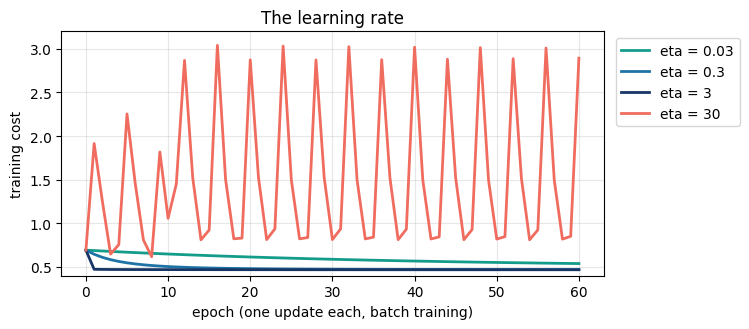

In [19]:
plt.figure(figsize=(7.6, 3.4))
for eta, color in zip((0.03, 0.3, 3, 30), ("#139C8A", "#1D73A6", "#173665", "#F06C5F")):
    _, _, hist = train_lr(S6_train, y_train, eta=eta, epochs=60, batch_size=len(y_train))
    plt.plot(hist, color=color, lw=2, label=f"eta = {eta}")
    print(f"eta = {eta:5}: training cost after 5 epochs {hist[5]:.3f}, after 60 epochs {hist[-1]:.3f}")
plt.xlabel("epoch (one update each, batch training)"); plt.ylabel("training cost")
plt.title("The learning rate"); plt.ylim(0.4, 3.2)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1)); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Scaling matters for gradient descent: the same learning rate on the features before standardization.

In [20]:
for eta in (0.3, 3):
    _, _, h_raw = train_lr(X6_train, y_train, eta=eta, epochs=60, batch_size=len(y_train))
    _, _, h_std = train_lr(S6_train, y_train, eta=eta, epochs=60, batch_size=len(y_train))
    print(f"eta = {eta}: cost after 60 epochs, raw features {h_raw[-1]:.3f}, standardized {h_std[-1]:.3f}")

eta = 0.3: cost after 60 epochs, raw features 0.480, standardized 0.471
eta = 3: cost after 60 epochs, raw features 2.136, standardized 0.468


Stochastic, mini-batch and batch training with the same learning rate, η = 0.1, on the word features. Each epoch processes all the training examples once, but with batches of size 1 there are 1500 updates per epoch, and with the whole training set only one. With single examples the updates are many but noisy, and the cost jumps up and down: the choppy movements of stochastic gradient descent. Averaging the gradient over a mini-batch smooths the updates while keeping many of them per epoch. Batch training makes one smooth update per epoch, and here it makes by far the slowest progress (the costs after 20 epochs are printed below the plot).

batch size    1: training cost after 20 epochs 0.482, increases from one epoch to the next: 9
batch size   16: training cost after 20 epochs 0.314, increases from one epoch to the next: 5
batch size  128: training cost after 20 epochs 0.350, increases from one epoch to the next: 1
batch size 1500: training cost after 20 epochs 0.574, increases from one epoch to the next: 0


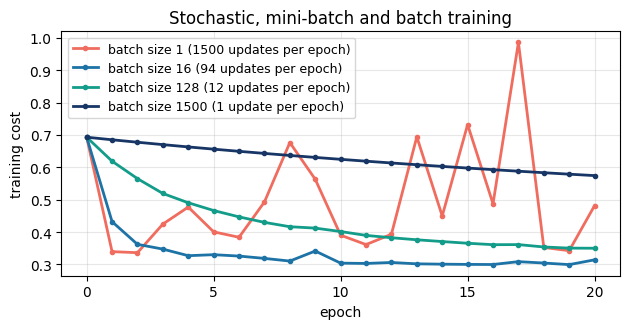

In [21]:
Xw_train = bow_matrix(train_data, vocab)
plt.figure(figsize=(6.4, 3.4))
for bs, color in zip((1, 16, 128, len(y_train)), ("#F06C5F", "#1D73A6", "#139C8A", "#173665")):
    _, _, hist = train_lr(Xw_train, y_train, eta=0.1, epochs=20, batch_size=bs)
    updates = -(-len(y_train) // bs)
    plt.plot(hist, color=color, lw=2, marker="o", ms=3, label=f"batch size {bs} ({updates} update{'s' if updates > 1 else ''} per epoch)")
    print(f"batch size {bs:4d}: training cost after 20 epochs {hist[-1]:.3f}, increases from one epoch to the next: {sum(b > a for a, b in zip(hist, hist[1:]))}")
plt.xlabel("epoch"); plt.ylabel("training cost"); plt.title("Stochastic, mini-batch and batch training")
plt.xticks(range(0, 21, 5))
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 11. What to do next

- The exercise sheet of this lecture: exercises 2 to 5 and 7 to 12 can be checked with the functions of sections 1 to 5, 7 and 8 (`nb_scores`, `sigmoid`, `logit`, `six_features`, `ce_loss`, `gradient`, `sgd_step`, `predict`, `batch_gradient`, and `statistics` for exercise 7).
- Change the templates of section 6: more negations, fewer exclamation marks, more label noise. How do the learned weights of section 8 and the accuracies of section 9 change?
- Implement binary Naive Bayes (Appendix B: each word counted at most once per document) and compare it with the multinomial version on the generated reviews.
- Add a feature template for bigrams to the word features of section 9 (*not boring* as one feature), and compare it with the NOT_ marking.
- Section 4.7 of the book extends logistic regression from two classes to many, with the softmax.